#  Debug CPA — Validation pas-à-pas
**Objectif :** Prouver que chaque étape de l'attaque CPA est correcte en inspectant les variables intermédiaires.  
**Hardware requis :** CW308 STM32F3 (pour la capture). Les traces sont ensuite sauvegardées pour rejouer sans hardware.

## Cellule 1 — Imports

In [12]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from IPython.core.debugger import set_trace
matplotlib.use('inline')
%matplotlib inline

# Import de toutes les fonctions du module
from cpa_core import (
    SBOX, KNOWN_KEY,
    hamming_weight,
    setup_scope, program_target, compile_firmware, capture_traces,
    _compute_leakage_model, _pearson_all_keys, _rank_and_expected,
    cpa_attack, cpa_attack_full, find_min_traces
)

PLATFORM   = 'CW308_STM32F4'
TRACES_FILE = 'debug_traces_F3.npz'
N_TRACES    = 100

print('✅ Imports OK')
print(f'Clé connue : {[hex(b) for b in KNOWN_KEY]}')

✅ Imports OK
Clé connue : ['0x2b', '0x7e', '0x15', '0x16', '0x28', '0xae', '0xd2', '0xa6', '0xab', '0xf7', '0x15', '0x88', '0x9', '0xcf', '0x4f', '0x3c']


In [13]:
# Compiler + flasher + capturer
print(PLATFORM)
compile_firmware(PLATFORM, '')
scope, target = setup_scope(PLATFORM)

try:
    program_target(scope, target, PLATFORM)
    traces, plaintexts = capture_traces(scope, target, N=N_TRACES, seed=42)
finally:
    scope.dis()
    target.dis()

# Sauvegarde pour rejouer sans hardware
np.savez(TRACES_FILE, traces=traces, plaintexts=plaintexts)
print(f'{len(traces)} traces sauvegardées dans {TRACES_FILE}')
print(f'Shape traces     : {traces.shape}')
print(f'Shape plaintexts : {plaintexts.shape}')

CW308_STM32F4

[COMPILE] Nettoyage : make PLATFORM=CW308_STM32F4 clean
[COMPILE] Build : make PLATFORM=CW308_STM32F4 CRYPTO_TARGET=TINYAES128C SS_VER=SS_VER_2_1 -j
Building for platform CW308_STM32F4 with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
arm-none-eabi-gcc (15:14.2.rel1-1) 14.2.1 20241119
Copyright (C) 2024 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CW308_STM32F4 
.
Welcome to another exciting ChipWhisperer target build!!
.
.
.
.
Compiling:
Compiling:
Compiling:
Compiling:
-en     simpleserial-aes.c ...
-en     .././simpleserial/simpleserial.c ...
-en     .././hal/hal.c ...
.
-en     .././hal/chipwhisperer-fw-extra/stm32f4/stm32f4_hal.c ...
Compiling:
.
.
-en     .././hal/chipwhisperer-fw-extra/stm32f4/stm32f4_hal_lowlevel.c ...
Compiling:
Compiling:

(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.64.0) is outdated - latest is 0.65.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


+--------------------------------------------------------
+ Default target does full rebuild each time.
+ Specify buildtarget == allquick == to avoid full rebuild
+--------------------------------------------------------
+--------------------------------------------------------
+ Built for platform CW308T: STM32F4 Target with:
+ CRYPTO_TARGET = TINYAES128C
+ CRYPTO_OPTIONS = AES128C
+--------------------------------------------------------
[COMPILE] OK
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                    

Capture traces: 100%|██████████| 100/100 [00:01<00:00, 59.17it/s]

[CAPTURE] 100 traces valides capturées
100 traces sauvegardées dans debug_traces_F3.npz
Shape traces     : (100, 5000)
Shape plaintexts : (100, 16)


## Cellule 3 — Charger les traces sauvegardées & inspection basique

Shape traces     : (100, 5000)   → (100 traces, 5000 échantillons)
Shape plaintexts : (100, 16) → (100 traces, 16 octets)
Min amplitude    : -0.5000
Max amplitude    : 0.4473
Moyenne          : -0.0031


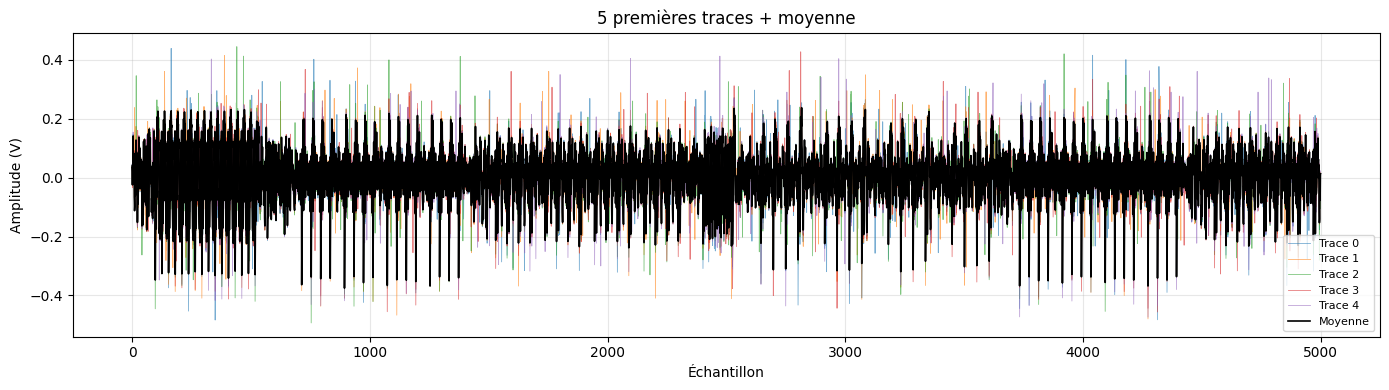

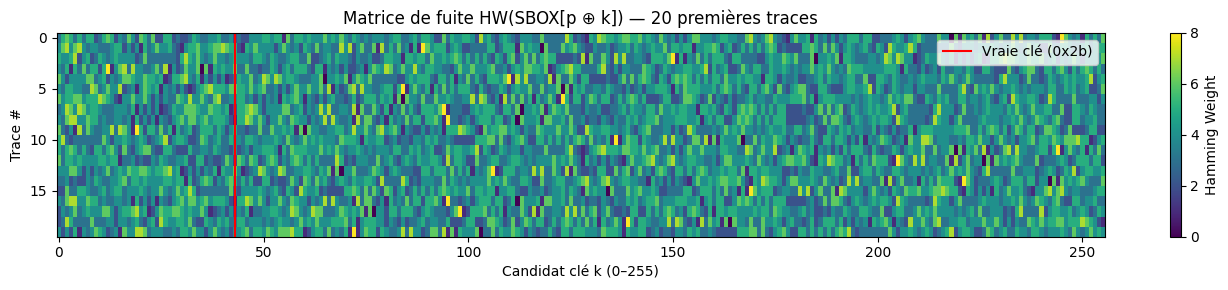

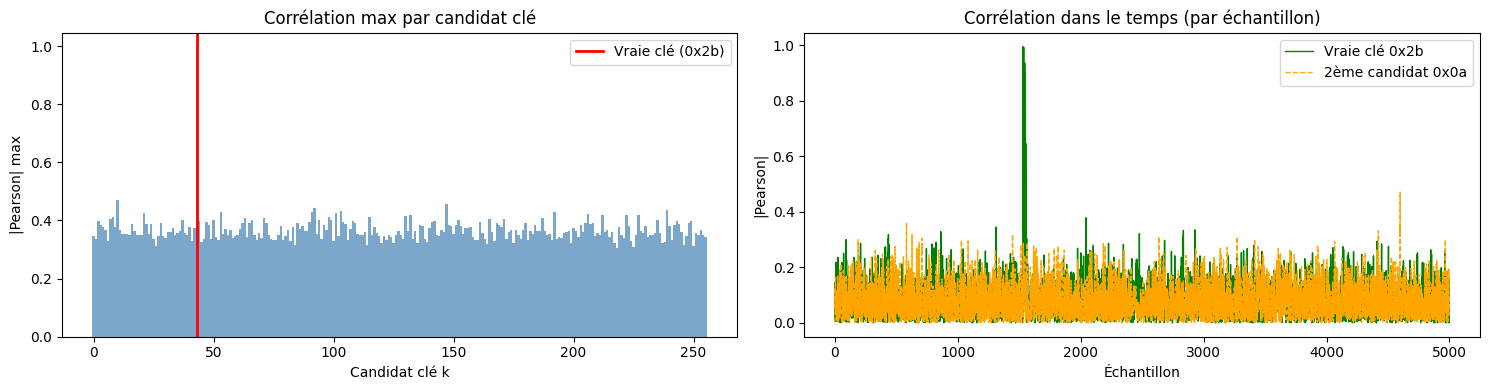

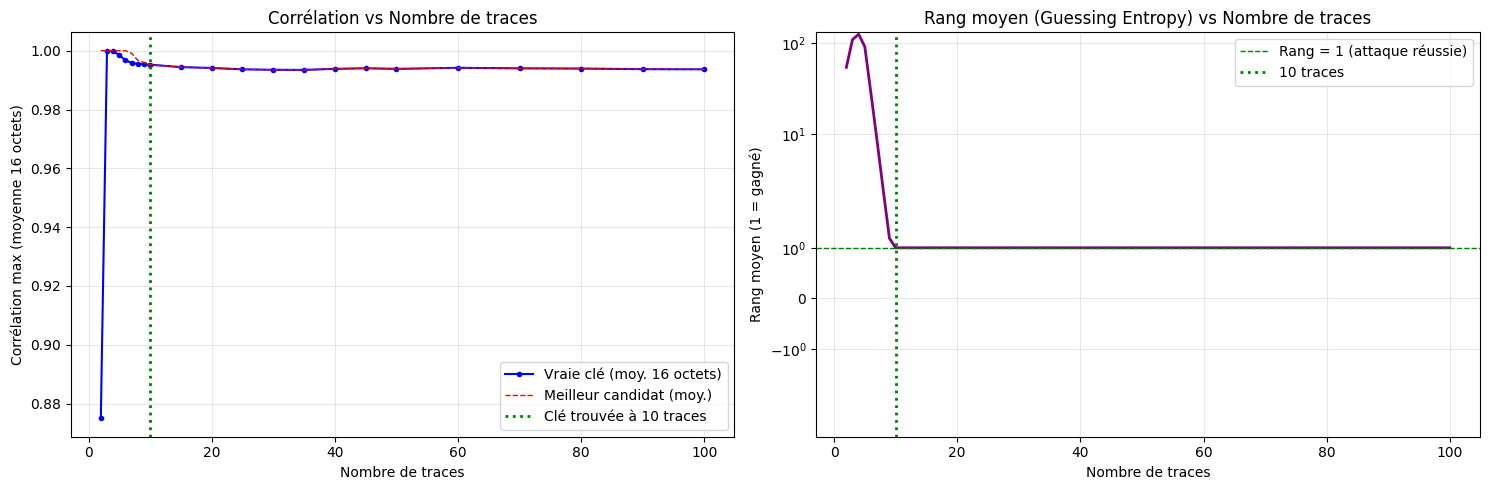

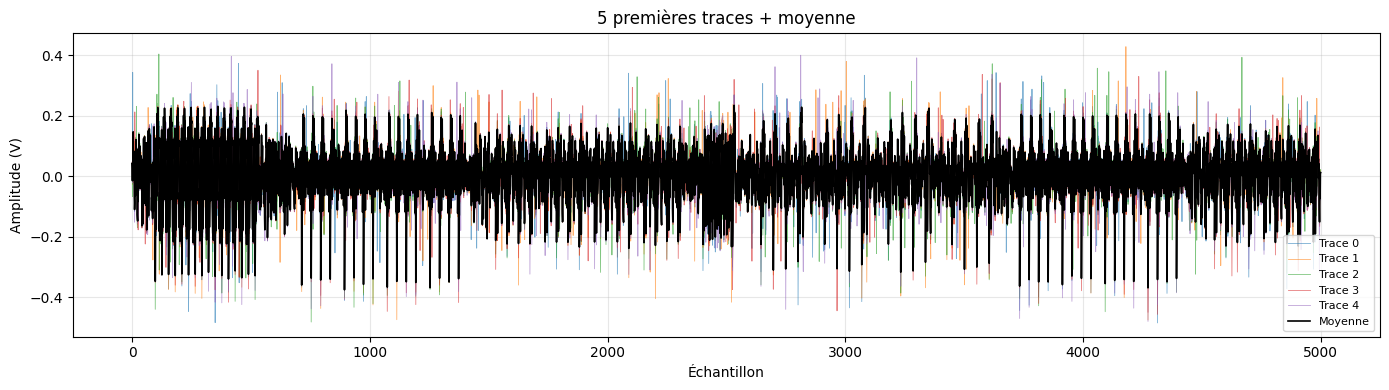

In [14]:
data = np.load(TRACES_FILE)
traces     = data['traces']
plaintexts = data['plaintexts']

print(f'Shape traces     : {traces.shape}   → ({traces.shape[0]} traces, {traces.shape[1]} échantillons)')
print(f'Shape plaintexts : {plaintexts.shape} → ({plaintexts.shape[0]} traces, {plaintexts.shape[1]} octets)')
print(f'Min amplitude    : {traces.min():.4f}')
print(f'Max amplitude    : {traces.max():.4f}')
print(f'Moyenne          : {traces.mean():.4f}')

# Afficher les 5 premières traces
fig, ax = plt.subplots(figsize=(14, 4))
for i in range(min(5, len(traces))):
    ax.plot(traces[i], alpha=0.6, linewidth=0.6, label=f'Trace {i}')
ax.plot(traces.mean(axis=0), color='black', linewidth=1.2, label='Moyenne')
ax.set_title('5 premières traces + moyenne')
ax.set_xlabel('Échantillon')
ax.set_ylabel('Amplitude (V)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cellule 4 — Vérification S-Box et `hamming_weight()`

In [15]:
# 1. Vérifier la S-Box AES
assert len(SBOX) == 256, f' SBOX doit avoir 256 valeurs, got {len(SBOX)}'
assert len(set(SBOX)) == 256, ' SBOX a des doublons !'
assert SBOX[0x00] == 0x63, f' SBOX[0x00] devrait être 0x63, got {hex(SBOX[0x00])}'
assert SBOX[0x01] == 0x7c, f' SBOX[0x01] devrait être 0x7c, got {hex(SBOX[0x01])}'
assert SBOX[0xff] == 0x16, f' SBOX[0xff] devrait être 0x16, got {hex(SBOX[0xff])}'
print(' S-Box AES correcte (256 valeurs, pas de doublons, valeurs spot-check OK)')

# 2. Vérifier hamming_weight
cas_tests = [(0x00, 0), (0x01, 1), (0xFF, 8), (0x55, 4), (0xAA, 4), (0x0F, 4)]
for val, expected in cas_tests:
    result = hamming_weight(val)
    status = 'YESSS' if result == expected else 'NO'
    print(f'  {status} HW(0x{val:02X}) = {result}  (attendu {expected})')

 S-Box AES correcte (256 valeurs, pas de doublons, valeurs spot-check OK)
  YESSS HW(0x00) = 0  (attendu 0)
  YESSS HW(0x01) = 1  (attendu 1)
  YESSS HW(0xFF) = 8  (attendu 8)
  YESSS HW(0x55) = 4  (attendu 4)
  YESSS HW(0xAA) = 4  (attendu 4)
  YESSS HW(0x0F) = 4  (attendu 4)


## Cellule 5 — Inspection de `_compute_leakage_model()`

5 premiers plaintexts[octet 0] : [136  36 235 113  19]
Clé attendue octet 0           : 0x2b

Shape leakage_matrix : (100, 256)  → (100 traces × 256 candidats clé)
Valeurs min/max      : 0 / 8  (attendu 0-8 car HW d'un octet)

Colonne vraie clé (0x2b) — moyenne HW : 4.020, std : 1.449
Colonne candidat faux         — moyenne HW : 3.860, std : 1.265


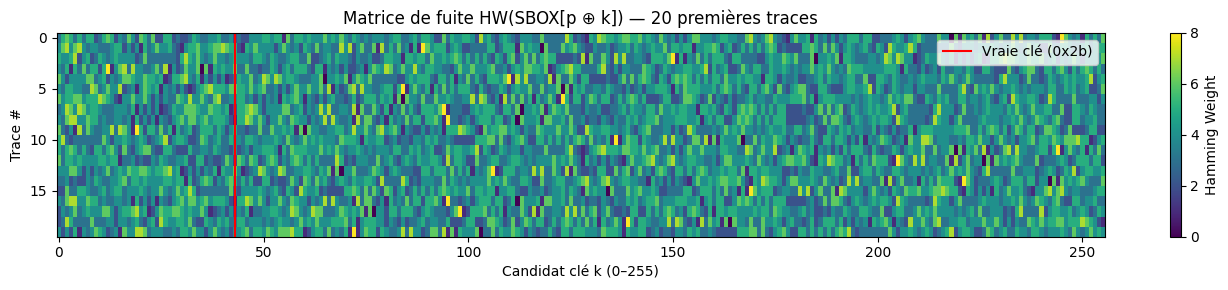

In [16]:
BYTE_IDX = 0  # On travaille sur l'octet 0 de la clé

plaintext_bytes = plaintexts[:, BYTE_IDX].astype(np.uint8)
print(f'5 premiers plaintexts[octet {BYTE_IDX}] : {plaintext_bytes[:5]}')
print(f'Clé attendue octet {BYTE_IDX}           : {hex(KNOWN_KEY[BYTE_IDX])}')

# Calcul de la matrice de fuite
leakage = _compute_leakage_model(plaintext_bytes)

print(f'\nShape leakage_matrix : {leakage.shape}  → ({leakage.shape[0]} traces × {leakage.shape[1]} candidats clé)')
print(f'Valeurs min/max      : {leakage.min():.0f} / {leakage.max():.0f}  (attendu 0-8 car HW d\'un octet)')

# Vérifier que la colonne de la vraie clé est remplie
true_key_byte = KNOWN_KEY[BYTE_IDX]
col_true = leakage[:, true_key_byte]
col_rand = leakage[:, (true_key_byte + 1) % 256]  # un candidat voisin
print(f'\nColonne vraie clé (0x{true_key_byte:02x}) — moyenne HW : {col_true.mean():.3f}, std : {col_true.std():.3f}')
print(f'Colonne candidat faux         — moyenne HW : {col_rand.mean():.3f}, std : {col_rand.std():.3f}')

# Heatmap des 10 premières traces × 256 candidats
fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(leakage[:20, :], aspect='auto', cmap='viridis', vmin=0, vmax=8)
ax.axvline(true_key_byte, color='red', linewidth=1.5, label=f'Vraie clé (0x{true_key_byte:02x})')
ax.set_title('Matrice de fuite HW(SBOX[p ⊕ k]) — 20 premières traces')
ax.set_xlabel('Candidat clé k (0–255)')
ax.set_ylabel('Trace #')
plt.colorbar(im, ax=ax, label='Hamming Weight')
ax.legend()
plt.tight_layout()
plt.show()

# Test de la fonction _pearson_all_keys()

In [17]:
import numpy as np
from scipy.spatial.distance import cdist

def test_pearson_full_matrix():
    """
    Prouve que notre fonction vectorisée génère EXACTEMENT la même matrice globale
    que NumPy et SciPy, sur toutes les hypothèses et tous les échantillons en même temps.
    """
    print("="*60)
    print(" TEST D'ÉQUIVALENCE MATRICIELLE (CUSTOM vs NUMPY vs SCIPY) ")
    print("="*60)
    
    #  Création de fausses données (on garde n_samples petit pour ne pas faire planter np.corrcoef)
    n_traces = 500
    n_keys = 256
    n_samples = 50 
    
    dummy_leakage = np.random.rand(n_traces, n_keys)    # (500, 256)
    dummy_traces = np.random.rand(n_traces, n_samples)  # (500, 50)
    
    print(f"[+] Dimensions : {n_traces} traces | {n_keys} hypothèses | {n_samples} échantillons")

    #ma fonction  
    our_matrix = _pearson_all_keys(dummy_leakage, dummy_traces)

    #methode SCIPY (cdist)
    # cdist s'attend à ce que les variables soient en lignes, d'où la transposée (.T)
    # La métrique de corrélation retourne une "distance", donc corrélation = 1 - distance
    distances = cdist(dummy_leakage.T, dummy_traces.T, metric='correlation')
    scipy_matrix = np.abs(1 - distances)

    # MÉTHODE 3 : NUMPY corrcoef
    combined_data = np.hstack([dummy_leakage, dummy_traces])
    
    # NumPy calcule tout avec tout -> génère une énorme matrice (306, 306)
    full_np_corr = np.corrcoef(combined_data, rowvar=False)
    
    # On extrait uniquement le bloc "Hypothèses vs Traces" en haut à droite
    # Les hypothèses sont de l'index 0 à 255. Les traces de l'index 256 à la fin.
    numpy_matrix = np.abs(full_np_corr[:n_keys, n_keys:])


    # np.allclose vérifie que toutes les cases des deux matrices sont identiques
    is_scipy_identical = np.allclose(our_matrix, scipy_matrix, atol=1e-10)
    is_numpy_identical = np.allclose(our_matrix, numpy_matrix, atol=1e-10)
    
    # Pour enfoncer le clou, on affiche la plus grande différence constatée (l'erreur maximale)
    max_error_scipy = np.max(np.abs(our_matrix - scipy_matrix))
    max_error_numpy = np.max(np.abs(our_matrix - numpy_matrix))

    print("\n--- RÉSULTATS ---")
    print(f"Équivalence avec SciPy validée ? : {' OUI' if is_scipy_identical else ' NON'} (Marge d'erreur max : {max_error_scipy:.2e})")
    print(f"Équivalence avec NumPy validée ? : {' OUI' if is_numpy_identical else ' NON'} (Marge d'erreur max : {max_error_numpy:.2e})")

# Lancer le test
test_pearson_full_matrix()

 TEST D'ÉQUIVALENCE MATRICIELLE (CUSTOM vs NUMPY vs SCIPY) 
[+] Dimensions : 500 traces | 256 hypothèses | 50 échantillons

--- RÉSULTATS ---
Équivalence avec SciPy validée ? :  OUI (Marge d'erreur max : 5.27e-16)
Équivalence avec NumPy validée ? :  OUI (Marge d'erreur max : 5.55e-17)


## Cellule 6 — Inspection de `_pearson_all_keys()`

Shape abs_corr : (256, 5000)  → (256 candidats × 5000 échantillons)
Valeurs dans [0, 1] : min=0.0000, max=0.9968

Meilleur candidat : 0x2b  (attendu 0x2b)
Corrélation max   : 0.9968
Corrélation vraie clé : 0.9968


/tmp/ipykernel_112147/2003167506.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


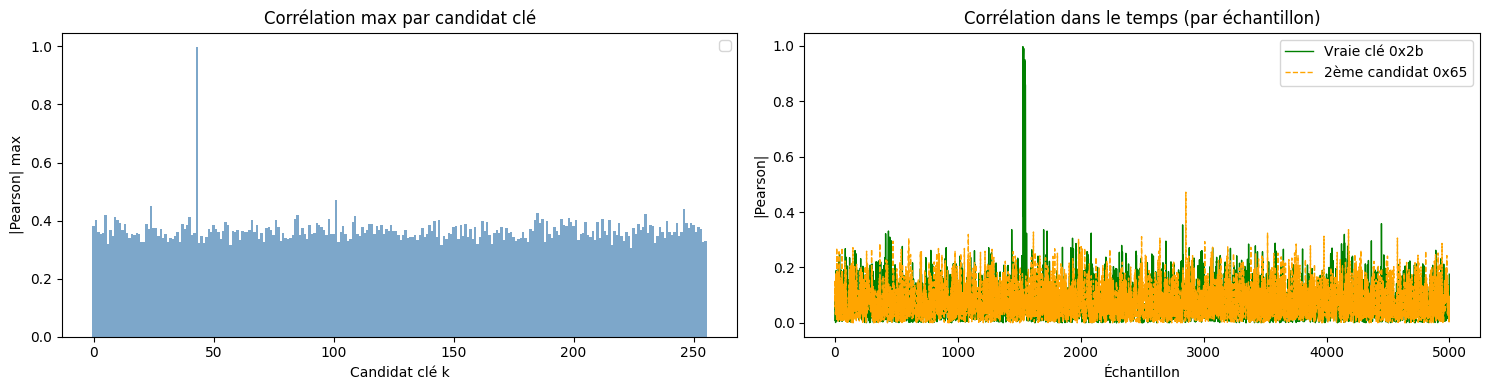

In [23]:
from logging import debug
%matplotlib inline
import matplotlib.pyplot as plt
# Calcul des corrélations
abs_corr = _pearson_all_keys(leakage, traces)
print(f'Shape abs_corr : {abs_corr.shape}  → (256 candidats × {abs_corr.shape[1]} échantillons)')
print(f'Valeurs dans [0, 1] : min={abs_corr.min():.4f}, max={abs_corr.max():.4f}')

# Max corrélation par candidat
max_corr_per_key = abs_corr.max(axis=1)
best_key = int(np.argmax(max_corr_per_key))
print(f'\nMeilleur candidat : 0x{best_key:02x}  (attendu 0x{KNOWN_KEY[BYTE_IDX]:02x})')
print(f'Corrélation max   : {max_corr_per_key[best_key]:.4f}')
print(f'Corrélation vraie clé : {max_corr_per_key[KNOWN_KEY[BYTE_IDX]]:.4f}')

# Graphe : corrélation max par candidat
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Gauche : corrélation max par candidat clé
axes[0].bar(range(256), max_corr_per_key, color='steelblue', alpha=0.7, width=1)
#axes[0].axvline(KNOWN_KEY[BYTE_IDX], color='red', linewidth=2, label=f'Vraie clé (0x{KNOWN_KEY[BYTE_IDX]:02x})')
axes[0].set_title('Corrélation max par candidat clé')
axes[0].set_xlabel('Candidat clé k')
axes[0].set_ylabel('|Pearson| max')
axes[0].legend()

# Droite : trace de corrélation pour vraie clé vs meilleur faux
axes[1].plot(abs_corr[KNOWN_KEY[BYTE_IDX]], label=f'Vraie clé 0x{KNOWN_KEY[BYTE_IDX]:02x}', color='green', linewidth=1)
second_best = int(np.argsort(max_corr_per_key)[-2])
axes[1].plot(abs_corr[second_best], label=f'2ème candidat 0x{second_best:02x}', color='orange', linewidth=1, linestyle='--')
axes[1].set_title('Corrélation dans le temps (par échantillon)')
axes[1].set_xlabel('Échantillon')
axes[1].set_ylabel('|Pearson|')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cellule 7 — `_rank_and_expected()` et rang de la vraie clé

In [19]:
corr_expected, rank = _rank_and_expected(max_corr_per_key, KNOWN_KEY[BYTE_IDX])

print(f'Corrélation vraie clé (0x{KNOWN_KEY[BYTE_IDX]:02x}) : {corr_expected:.4f}')
print(f'Rang de la vraie clé : {rank} / 256')
print()
if rank == 1:
    print('✅ Rang = 1 : la vraie clé est le meilleur candidat → attaque réussie !')
else:
    print(f'⚠️  Rang = {rank} : la vraie clé n\'est pas en tête — plus de traces nécessaires.')

# Top 5 des candidats
top5_idx = np.argsort(max_corr_per_key)[::-1][:5]
print('\nTop 5 candidats :')
for pos, idx in enumerate(top5_idx):
    marker = '' if idx == KNOWN_KEY[BYTE_IDX] else ''
    print(f'  #{pos+1}  0x{idx:02x}  corr={max_corr_per_key[idx]:.4f}{marker}')

Corrélation vraie clé (0x2b) : 0.9968
Rang de la vraie clé : 1 / 256

✅ Rang = 1 : la vraie clé est le meilleur candidat → attaque réussie !

Top 5 candidats :
  #1  0x2b  corr=0.9968
  #2  0x65  corr=0.4716
  #3  0x18  corr=0.4516
  #4  0xf6  corr=0.4413
  #5  0xb9  corr=0.4260


## Cellule 8 — `cpa_attack()` via la fonction (vérification du résultat)

In [20]:
best_key_fn, max_corr_fn, rank_fn, corr_expected_fn = cpa_attack(traces, plaintexts, byte=BYTE_IDX)

print(f'Résultat via cpa_attack(byte={BYTE_IDX}) :')
print(f'  Meilleur candidat : 0x{best_key_fn:02x}  (attendu 0x{KNOWN_KEY[BYTE_IDX]:02x})')
print(f'  Corrélation max   : {max_corr_fn:.4f}')
print(f'  Rang vraie clé    : {rank_fn}')
print(f'  Corr vraie clé    : {corr_expected_fn:.4f}')
print()

# Vérification cohérence avec calcul manuel (cellules 5-7)
assert best_key_fn == best_key, f'❌ Incohérence best_key: {best_key_fn} vs {best_key}'
assert rank_fn == rank, f'❌ Incohérence rang: {rank_fn} vs {rank}'
print('✅ Résultat cohérent avec le calcul manuel des cellules 5-7')

Résultat via cpa_attack(byte=0) :
  Meilleur candidat : 0x2b  (attendu 0x2b)
  Corrélation max   : 0.9968
  Rang vraie clé    : 1
  Corr vraie clé    : 0.9968

✅ Résultat cohérent avec le calcul manuel des cellules 5-7


## Cellule 9 — `cpa_attack_full()` sur les 16 octets

In [21]:
best_keys, max_corrs, ranks, expected_corrs = cpa_attack_full(traces, plaintexts)

# Tableau récapitulatif
print(f'{"Octet":>6} | {"Trouvée":>8} | {"Attendue":>8} | {"OK":>3} | {"Corr":>6} | {"Rang":>4}')
print('-' * 55)
for b in range(16):
    ok = '✅' if best_keys[b] == KNOWN_KEY[b] else '❌'
    print(f'  [{b:02d}]  | 0x{best_keys[b]:02x}     | 0x{KNOWN_KEY[b]:02x}     | {ok}  | {max_corrs[b]:.4f} | {ranks[b]:4d}')

found_all = list(best_keys) == list(KNOWN_KEY)
print()
if found_all:
    print('✅ Clé complète trouvée correctement !')
    print(f'Clé : {" ".join([f"{k:02x}" for k in best_keys])}')
else:
    n_ok = sum(1 for b in range(16) if best_keys[b] == KNOWN_KEY[b])
    print(f'⚠️  {n_ok}/16 octets corrects — augmenter N_TRACES')

 Octet |  Trouvée | Attendue |  OK |   Corr | Rang
-------------------------------------------------------
  [00]  | 0x2b     | 0x2b     | ✅  | 0.9968 |    1
  [01]  | 0x7e     | 0x7e     | ✅  | 0.9933 |    1
  [02]  | 0x15     | 0x15     | ✅  | 0.9911 |    1
  [03]  | 0x16     | 0x16     | ✅  | 0.9942 |    1
  [04]  | 0x28     | 0x28     | ✅  | 0.9948 |    1
  [05]  | 0xae     | 0xae     | ✅  | 0.9952 |    1
  [06]  | 0xd2     | 0xd2     | ✅  | 0.9946 |    1
  [07]  | 0xa6     | 0xa6     | ✅  | 0.9943 |    1
  [08]  | 0xab     | 0xab     | ✅  | 0.9940 |    1
  [09]  | 0xf7     | 0xf7     | ✅  | 0.9908 |    1
  [10]  | 0x15     | 0x15     | ✅  | 0.9954 |    1
  [11]  | 0x88     | 0x88     | ✅  | 0.9944 |    1
  [12]  | 0x09     | 0x09     | ✅  | 0.9945 |    1
  [13]  | 0xcf     | 0xcf     | ✅  | 0.9938 |    1
  [14]  | 0x4f     | 0x4f     | ✅  | 0.9940 |    1
  [15]  | 0x3c     | 0x3c     | ✅  | 0.9913 |    1

✅ Clé complète trouvée correctement !
Clé : 2b 7e 15 16 28 ae d2 a6 ab f7 15

## Cellule 10 — `find_min_traces()` : convergence de l'attaque

Nombre de checkpoints testés : 22
Clé complète trouvée à       : 10 traces


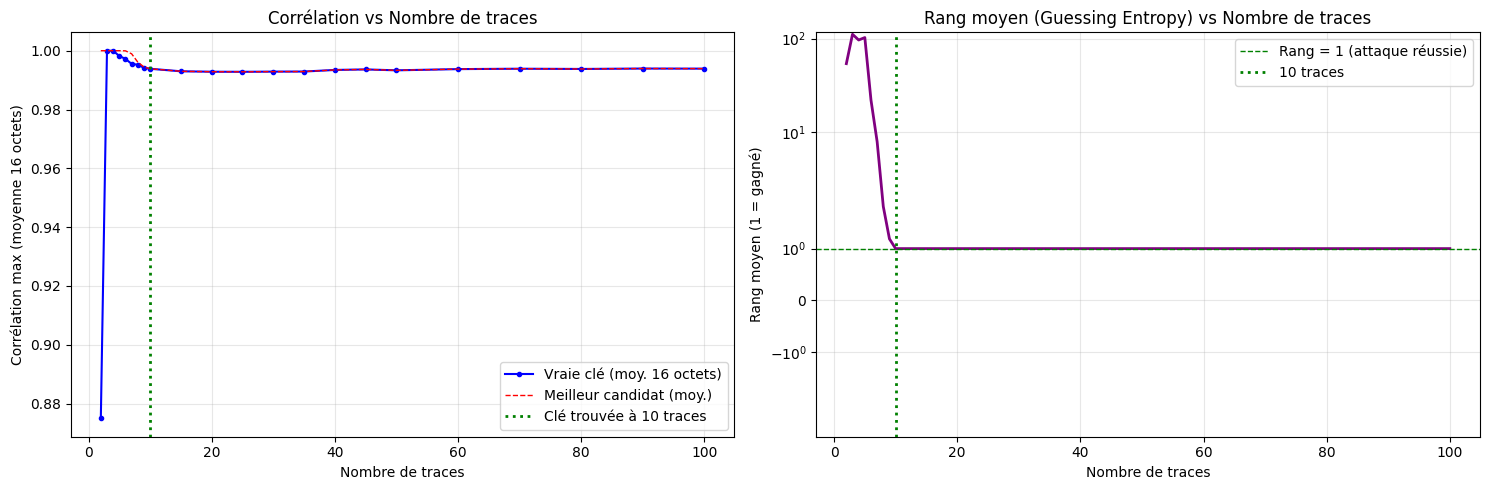

In [22]:
checkpoints, corr_correct, corr_best, found_at, ranks_history = find_min_traces(traces, plaintexts)

print(f'Nombre de checkpoints testés : {len(checkpoints)}')
print(f'Clé complète trouvée à       : {found_at} traces' if found_at else '⚠️ Clé complète non trouvée')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gauche : corrélation en fonction du nombre de traces
axes[0].plot(checkpoints, corr_correct, 'b-o', markersize=3, label='Vraie clé (moy. 16 octets)')
axes[0].plot(checkpoints, corr_best, 'r--', linewidth=1, label='Meilleur candidat (moy.)')
if found_at:
    axes[0].axvline(found_at, color='green', linestyle=':', linewidth=2, label=f'Clé trouvée à {found_at} traces')
axes[0].set_title('Corrélation vs Nombre de traces')
axes[0].set_xlabel('Nombre de traces')
axes[0].set_ylabel('Corrélation max (moyenne 16 octets)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Droite : rang moyen en fonction du nombre de traces
axes[1].plot(checkpoints, ranks_history, 'purple', linewidth=2)
axes[1].axhline(1, color='green', linestyle='--', linewidth=1, label='Rang = 1 (attaque réussie)')
if found_at:
    axes[1].axvline(found_at, color='green', linestyle=':', linewidth=2, label=f'{found_at} traces')
axes[1].set_title('Rang moyen (Guessing Entropy) vs Nombre de traces')
axes[1].set_xlabel('Nombre de traces')
axes[1].set_ylabel('Rang moyen (1 = gagné)')
axes[1].set_yscale('symlog')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()